## Imports, reading data etc

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import STL

In [36]:
df2906_1 = pd.read_csv('../data/labeled/no_plug/2906-1.csv')
df3006_1 = pd.read_csv('../data/labeled/no_plug/3006-1.csv')
df3006_2 = pd.read_csv('../data/labeled/no_plug/3006-2.csv')
df0404 = pd.read_csv('../data/labeled/no_plug/0404.csv')
df0712 = pd.read_csv('../data/labeled/no_plug/0712.csv')
df1703 = pd.read_csv('../data/labeled/no_plug/1703.csv')

df1803 = pd.read_csv('../data/labeled/partial_plug/1803.csv')
df1103 = pd.read_csv('../data/labeled/partial_plug/1103.csv')
df2503 = pd.read_csv('../data/labeled/partial_plug/2503.csv')
df2108_1 = pd.read_csv('../data/labeled/partial_plug/2108-1.csv')

df0709 = pd.read_csv('../data/labeled/plug/0709.csv')
df2106_2 = pd.read_csv('../data/labeled/plug/2106-2.csv')
df2108_2 = pd.read_csv('../data/labeled/plug/2108-2.csv')
df2906_2 = pd.read_csv('../data/labeled/plug/2906-2.csv')
df2906_3 = pd.read_csv('../data/labeled/plug/2906-3.csv')
df2906_4 = pd.read_csv('../data/labeled/plug/2906-4.csv')
df3006_3 = pd.read_csv('../data/labeled/plug/3006-3.csv')
df0612_2 = pd.read_csv('../data/labeled/plug/0612-2.csv')
df0612_3 = pd.read_csv('../data/labeled/plug/0612-3.csv')
df0707_1 = pd.read_csv('../data/labeled/plug/0707-1.csv')
df0707_2 = pd.read_csv('../data/labeled/plug/0707-2.csv')
df0707_4 = pd.read_csv('../data/labeled/plug/0707-4.csv')
df1112 = pd.read_csv('../data/labeled/plug/1112.csv')
df1310_2 = pd.read_csv('../data/labeled/plug/1310-2.csv')
df1310_3 = pd.read_csv('../data/labeled/plug/1310-3.csv')
df1407_1 = pd.read_csv('../data/labeled/plug/1407-1.csv')
df1407_2 = pd.read_csv('../data/labeled/plug/1407-2.csv')
df1407_3 = pd.read_csv('../data/labeled/plug/1407-3.csv')
df1407_4 = pd.read_csv('../data/labeled/plug/1407-4.csv')
df1503 = pd.read_csv('../data/labeled/plug/1503.csv')
df1811 = pd.read_csv('../data/labeled/plug/1811.csv')
df2701 = pd.read_csv('../data/labeled/plug/2701.csv')
df1003 = pd.read_csv('../data/labeled/plug/1003.csv')

In [37]:
no_plug_dfs = [df1703, df2906_1, df3006_1, df3006_2, df0404, df0712]

no_plug_names = ['1703', '2906-1', '3006-1', '3006-2', '0404', '0712']

plug_dfs = [df1003, df0709, df2106_2, df2108_2, df2906_2, df2906_3, df2906_4, 
            df3006_3, df0612_2, df0612_3, df0707_1, df0707_2, df0707_4, df1112, 
            df1310_2, df1310_3, df1407_1, df1407_2, df1407_3, df1407_4, df1503, df1811, df2701]

plug_names = ['1003', '0709', '2106-2', '2108-2', '2906-2', '2906-3', '2906-4',
           '3006-3', '0612-2', '0612-3', '0707-1', '0707-2', '0707-4', '1112',
           '1310-2', '1310-3', '1407-1', '1407-2', '1407-3', '1407-4', '1503', '1811', '2701']

partial_plug_dfs = [df1803, df1103, df2503, df2108_1]
partial_plug_names = ['1803', '1103', '2503', '2108-1']

In [38]:
for i in range(len(partial_plug_dfs)):
    if partial_plug_dfs[0].columns.all() != partial_plug_dfs[i].columns.all():
        print('mismatch!')
for i in range(len(no_plug_dfs)):
    if no_plug_dfs[0].columns.all() != no_plug_dfs[i].columns.all():
        print('mismatch!')
for i in range(len(plug_dfs)):
    if plug_dfs[0].columns.all() != plug_dfs[i].columns.all():
        print('mismatch!')

## Unsupervised 

In [39]:
def extract_features(df_list):
    all_features = []
    processed_dfs = []
    
    for df in df_list:
        temp = df.copy()
       
        base_tot_dp = temp['Total system DP'].iloc[:60].median()
        temp['rel_tot_dp_change'] = temp['Total system DP'] / base_tot_dp

        base_ts_dp = temp['Differential pressure (Mean)'].iloc[:60].median()
        temp['rel_ts_dp_change'] = temp['Differential pressure (Mean)'] / base_ts_dp
        base_p_ts_dp = temp['Pump to inlet DP'].iloc[:60].median()
        temp['rel_p_ts_dp_change'] = temp['Pump to inlet DP'] / base_p_ts_dp
        
        temp = temp.dropna()
        processed_dfs.append(temp)

        features = ['rel_p_ts_dp_change', 'rel_ts_dp_change', 'rel_tot_dp_change']
        all_features.append(temp[features])
        
    return pd.concat(all_features), processed_dfs

In [40]:
X_train_raw, clean_processed = extract_features(no_plug_dfs)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)

In [41]:
model = IsolationForest(
    n_estimators=300, 
    contamination=0.015,
    random_state=42
)
model.fit(X_train_scaled)

IsolationForest(contamination=0.015, n_estimators=300, random_state=42)

In [42]:
_, plug_processed = extract_features(plug_dfs)

scored_plug_dfs = []
features_list = ['rel_p_ts_dp_change', 'rel_ts_dp_change', 'rel_tot_dp_change']

for df in plug_processed:
    temp = df.copy()
    X_test = scaler.transform(temp[features_list])
    
    temp['anomaly_score'] = model.decision_function(X_test)
    
    temp['smooth_score'] = temp['anomaly_score'].rolling(window=1).mean()
    scored_plug_dfs.append(temp)

In [43]:
scored_clean_dfs = []
for df in clean_processed:
    temp = df.copy()
    X_test = scaler.transform(temp[features_list])
    temp['anomaly_score'] = model.decision_function(X_test)
    temp['smooth_score'] = temp['anomaly_score'].rolling(window=1).mean()
    scored_clean_dfs.append(temp)

min_n = min([df['smooth_score'].dropna().min() for df in scored_clean_dfs])
min_p = min([df['smooth_score'].dropna().min() for df in scored_plug_dfs])

print(f"Deepest Anomaly in Normal Runs: {min_n:.4f}")
print(f"Deepest Anomaly in Plug Runs:   {min_p:.4f}")

Deepest Anomaly in Normal Runs: -0.0581
Deepest Anomaly in Plug Runs:   -0.1067


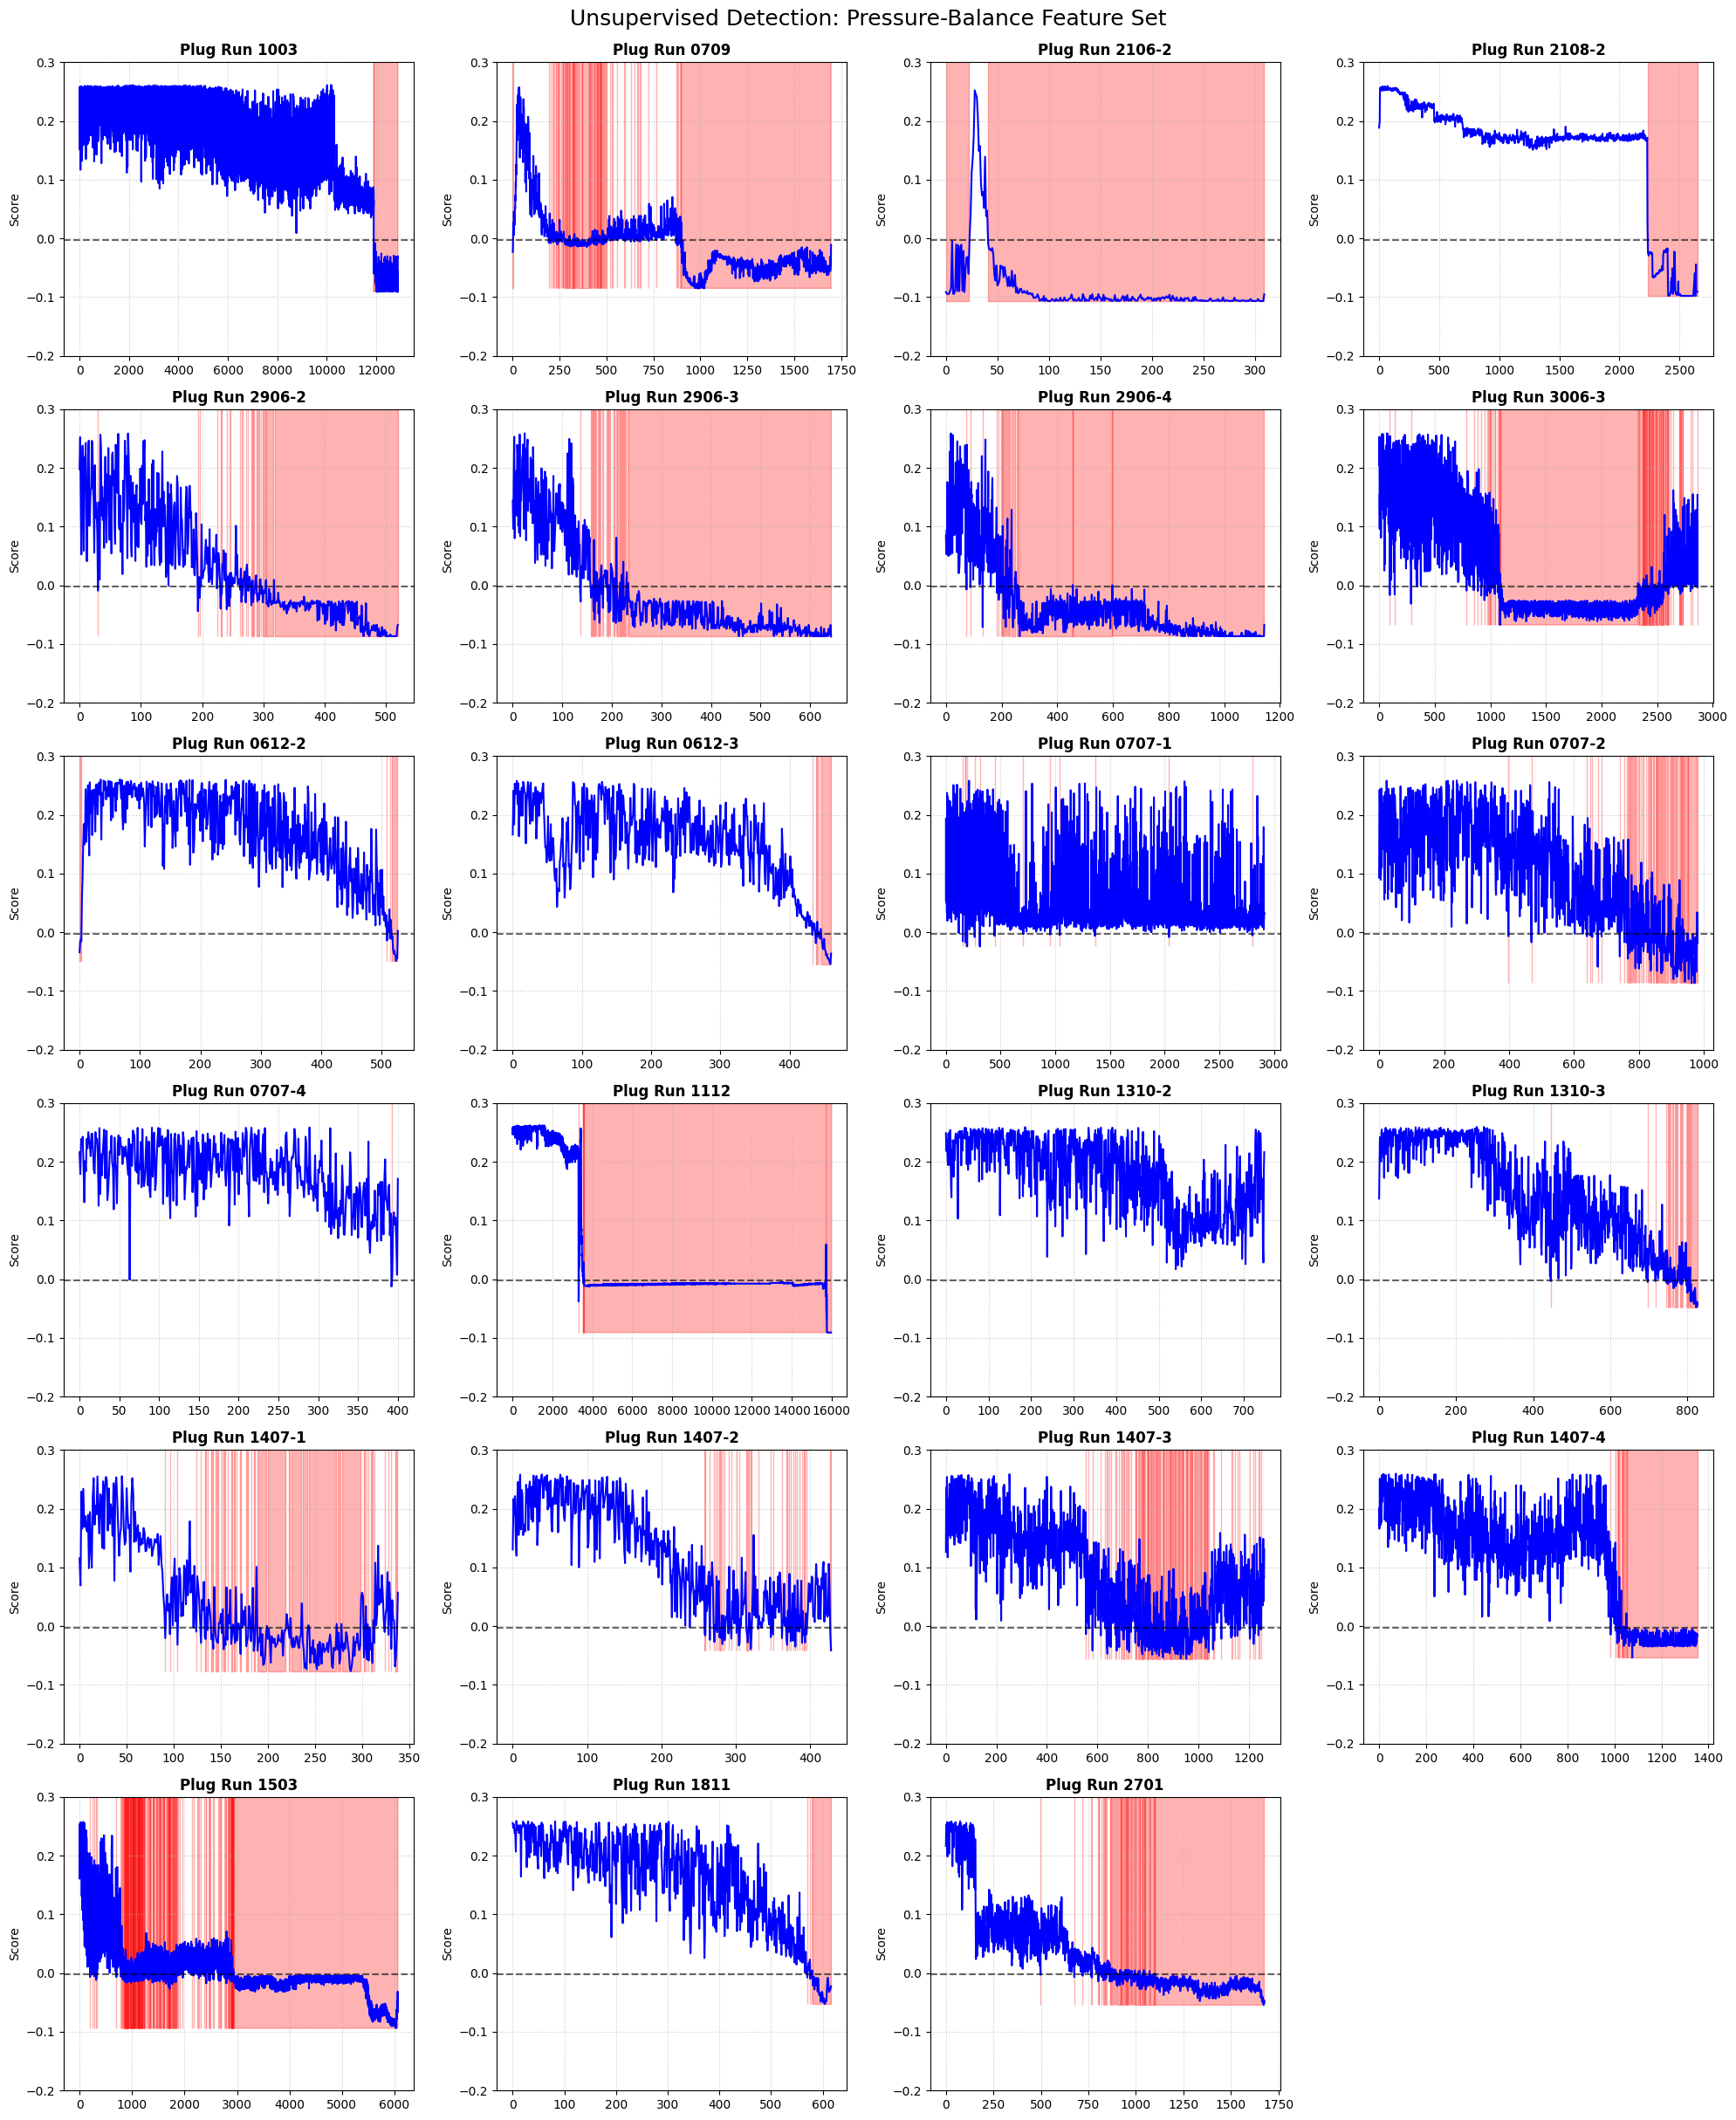

In [44]:
# 1. Configuration
threshold = -0.0025
cols = 4
rows = math.ceil(len(scored_plug_dfs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, df in enumerate(scored_plug_dfs):
    ax = axes[i]
    
    # Logic: 1 if anomaly, 0 if normal
    df['is_alert'] = (df['smooth_score'] < threshold).astype(int)
    
    # Plot the smoothed anomaly score
    ax.plot(df.index, df['smooth_score'], color='blue', linewidth=1.5, label='Anomaly Score')
    
    # Highlight the 'Alert' regions in red
    ax.fill_between(df.index, df['smooth_score'].min(), 0.5, 
                    where=df['is_alert']==1, color='red', alpha=0.3)
    
    # Threshold Line
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6)
    
    ax.set_title(f"Plug Run {plug_names[i]}", fontweight='bold')
    ax.set_ylabel("Score")
    ax.set_ylim([-0.2, 0.3])
    ax.grid(True, linestyle=':', alpha=0.7)

# Cleanup unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f"Unsupervised Detection: Pressure-Balance Feature Set", fontsize=18, y=1.01)
plt.show()

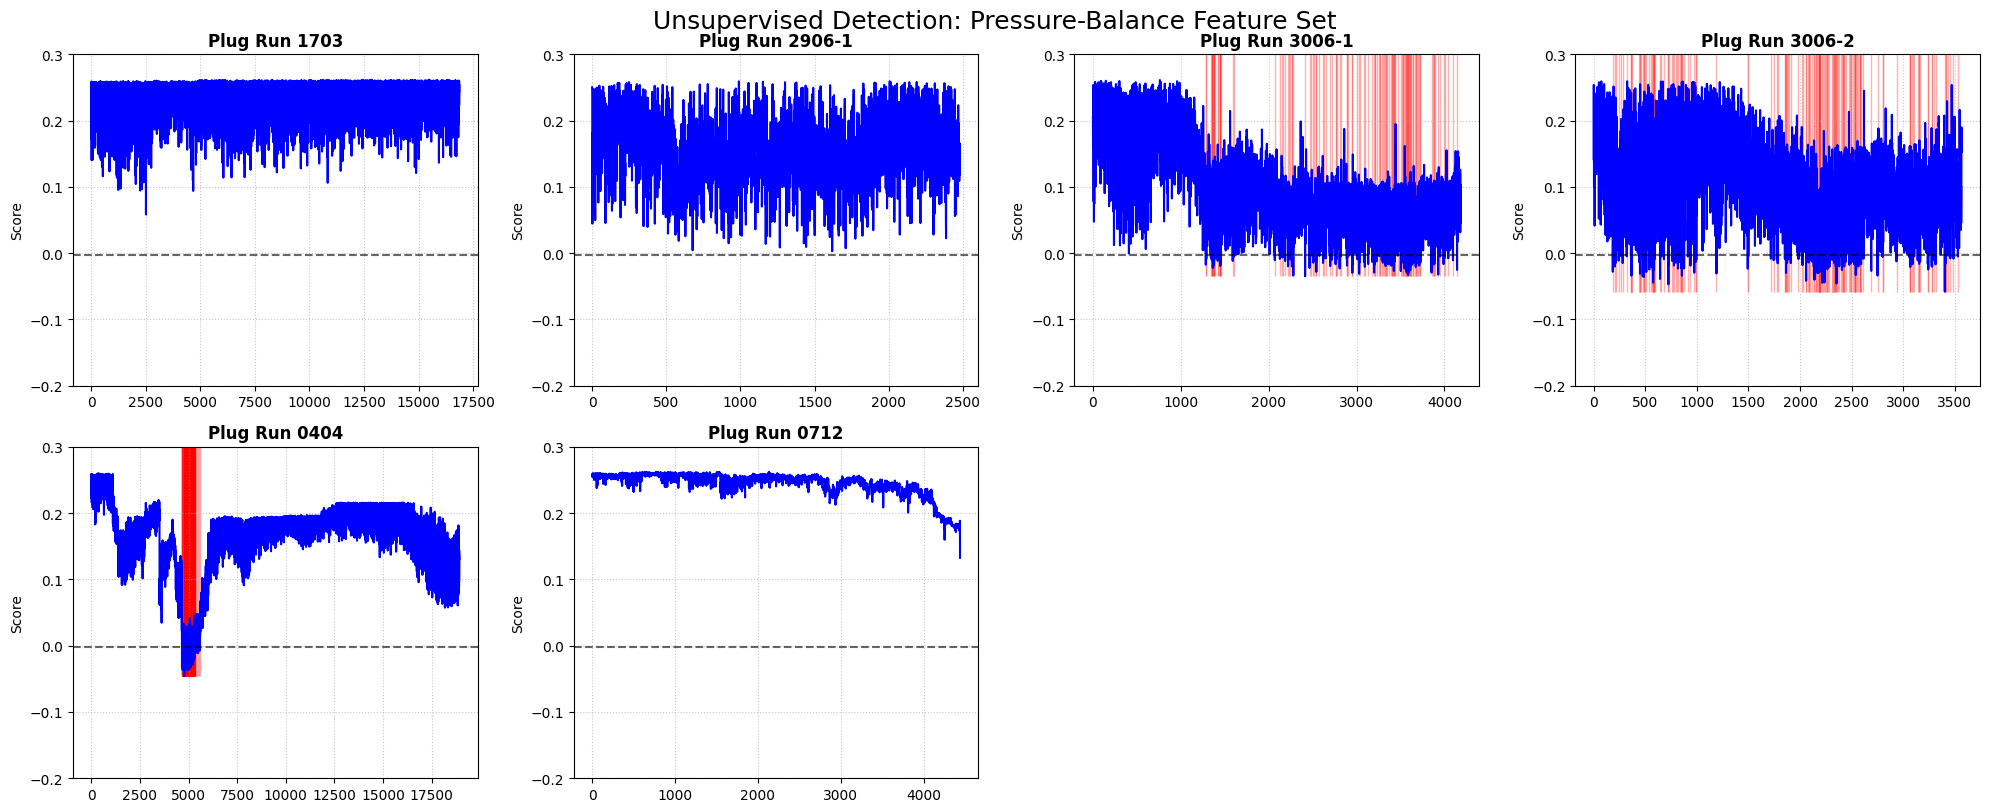

In [46]:
# 1. Configuration
threshold = -0.0025
cols = 4
rows = math.ceil(len(scored_clean_dfs) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, df in enumerate(scored_clean_dfs):
    ax = axes[i]
    
    # Logic: 1 if anomaly, 0 if normal
    df['is_alert'] = (df['smooth_score'] < threshold).astype(int)
    
    # Plot the smoothed anomaly score
    ax.plot(df.index, df['smooth_score'], color='blue', linewidth=1.5, label='Anomaly Score')
    
    # Highlight the 'Alert' regions in red
    ax.fill_between(df.index, df['smooth_score'].min(), 0.5, 
                    where=df['is_alert']==1, color='red', alpha=0.3)
    
    # Threshold Line
    ax.axhline(y=threshold, color='black', linestyle='--', alpha=0.6)
    
    ax.set_title(f"Plug Run {no_plug_names[i]}", fontweight='bold')
    ax.set_ylabel("Score")
    ax.set_ylim([-0.2, 0.3])
    ax.grid(True, linestyle=':', alpha=0.7)

# Cleanup unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.suptitle(f"Unsupervised Detection: Pressure-Balance Feature Set", fontsize=18, y=1.01)
plt.show()

PCA for featrure importance


In [45]:
"""for i, df in enumerate(scored_plug_dfs):
    df.to_csv(f'../data/labeledAndAnomaly/plug/{p_names[i]}.csv', index=False)

for i, df in enumerate(scored_clean_dfs):
    df.to_csv(f'../data/labeledAndAnomaly/no_plug/{no_p_names[i]}.csv', index=False)"""

"for i, df in enumerate(scored_plug_dfs):\n    df.to_csv(f'../data/labeledAndAnomaly/plug/{p_names[i]}.csv', index=False)\n\nfor i, df in enumerate(scored_clean_dfs):\n    df.to_csv(f'../data/labeledAndAnomaly/no_plug/{no_p_names[i]}.csv', index=False)"